<a href="https://colab.research.google.com/github/bidallei/MIAAD-UACJ/blob/main/ActividadEtiquetadoGramatical.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Actividad - Etiquetado gramatical**

* Asignatura: Procesamiento del Lenguaje Natural
* Profesor: Dr. Rogelio Florencia Juárez
* Alumno: **Álvaro Hernández Jarquín**
* Matrícula: 263150
* 15 de marzo de 2026




Aplique los conceptos de etiquetado gramatical vistos en clase mediante el análisis de un texto en español, y realizar un análisis exploratorio de datos sencillo a partir de las etiquetas obtenidas. El texto para analizar se presenta a continuación:

`En los últimos años, muchas universidades han incorporado herramientas digitales para apoyar el aprendizaje de los estudiantes. Estas tecnologías permiten organizar materiales, facilitar la comunicación y ofrecer actividades interactivas dentro y fuera del aula. Sin embargo, su uso no siempre garantiza mejores resultados académicos, porque también depende de la planeación del docente y del compromiso del alumno. En algunos cursos, los estudiantes participan más cuando utilizan plataformas virtuales, foros o sistemas de retroalimentación inmediata. Además, los profesores pueden analizar con mayor facilidad el avance del grupo y detectar dificultades en temas específicos. Por esta razón, el uso de recursos tecnológicos se ha convertido en un tema relevante para la educación actual.`

### **Instrucciones:**

Aplique los conceptos de etiquetado gramatical vistos en clase mediante el análisis de un texto en español, y realizar un análisis exploratorio de datos sencillo a partir de las etiquetas obtenidas. El texto para analizar se presenta a continuación:

1.	Divida el texto en tokens.
2.	Asigne a cada token su etiqueta gramatical correspondiente utilizando alguno de los ejemplos de la presentación del tema que está en el campus virtual.
3.	Realice un análisis exploratorio de datos con la información obtenida donde muestre:
  * a. El número total de tokens
  * b.	Número de tokens distintos
  * c.	Conteo de cada categoría gramatical en una gráfica de barras
  * d.	Los cinco tokens más frecuentes del texto con sus respectivas etiquetas gramaticales en una gráfica de barras
  * e.	Las tres clases gramaticales más frecuentes del texto en una gráfica de barras
4.	Redacte una conclusión sobre el texto y su etiquetado gramatical.


**Entregables:**
* Script de Python con las implementaciones realizadas (si no desea subir el script, puede copiar y pegar el código y los solicitado en la actividad en un documento de word).


In [10]:
# Instalamos e importamos spacy
!python -m spacy download es_core_news_sm

import spacy
from spacy import displacy
from collections import Counter
import matplotlib.pyplot as plt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 73.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [8]:
# Modelo en español
nlp = spacy.load("es_core_news_sm")

# Frase
texto = '''
En los últimos años, muchas universidades han incorporado herramientas digitales para apoyar el aprendizaje de los estudiantes. Estas tecnologías permiten organizar materiales, facilitar la comunicación y ofrecer actividades interactivas dentro y fuera del aula. Sin embargo, su uso no siempre garantiza mejores resultados académicos, porque también depende de la planeación del docente y del compromiso del alumno. En algunos cursos, los estudiantes participan más cuando utilizan plataformas virtuales, foros o sistemas de retroalimentación inmediata. Además, los profesores pueden analizar con mayor facilidad el avance del grupo y detectar dificultades en temas específicos. Por esta razón, el uso de recursos tecnológicos se ha convertido en un tema relevante para la educación actual.
'''

# Procesa la oración
doc = nlp(texto)

# Filtramos los espacios en blanco
tokens_validos = [token for token in doc if not token.is_space]

In [20]:
# Total de tokens
total_tokens = len(tokens_validos)

# Tokens distintos en minúsculas
tokens_distintos = len(set([t.text.lower() for t in tokens_validos]))

print(f"a. Número total de tokens: {total_tokens}")
print(f"b. Número de tokens distintos: {tokens_distintos}\n")

a. Número total de tokens: 125
b. Número de tokens distintos: 90



In [18]:
# --- Categorización gramatical, tokens y clases ---

# Por categoría gramatical
pos_counts = Counter([t.pos_ for t in tokens_validos])
pos_labels, pos_values = zip(*pos_counts.most_common())

# Cinco tokens más frecuentes con su etiqueta. Sin comas o puntos
tokens_palabras = [t for t in tokens_validos if not t.is_punct]
top5_tokens = Counter([f"{t.text.lower()} ({t.pos_})" for t in tokens_palabras]).most_common(5)
top5_labels, top5_values = zip(*top5_tokens)

# Tres clases gramaticales más frecuentes
top3_pos = pos_counts.most_common(3)
top3_labels, top3_values = zip(*top3_pos)

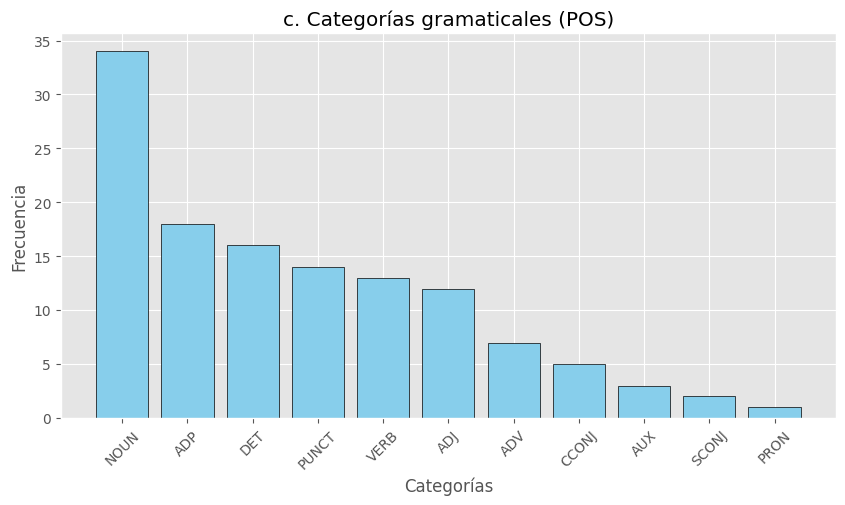

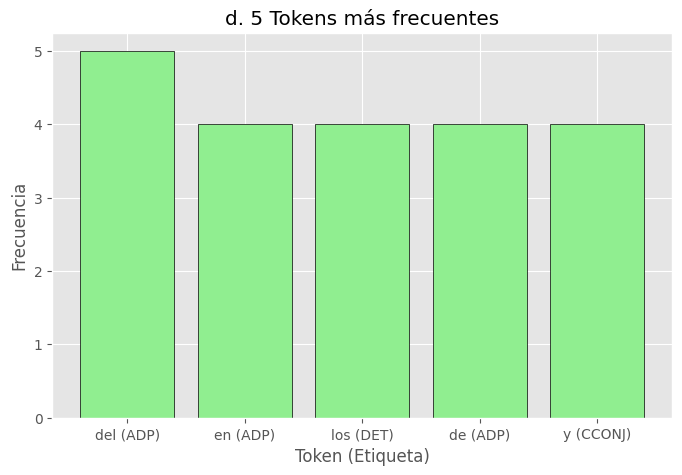

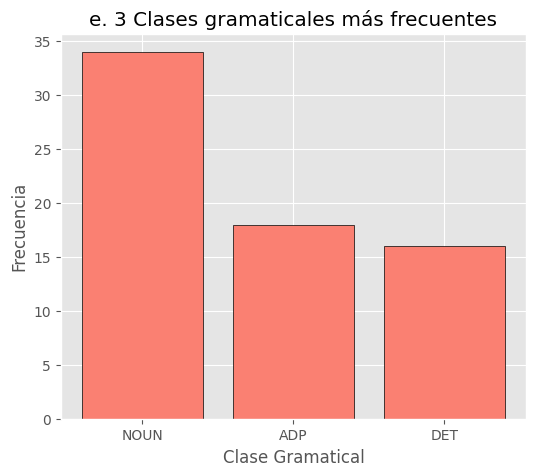

In [21]:
# Visualización de datos
plt.style.use('ggplot')

# Categorías gramaticales
plt.figure(figsize=(10, 5))
plt.bar(pos_labels, pos_values, color='skyblue', edgecolor='black')
plt.title("c. Categorías gramaticales (POS)")
plt.xlabel("Categorías")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.show()

# Top 5 Tokens
plt.figure(figsize=(8, 5))
plt.bar(top5_labels, top5_values, color='lightgreen', edgecolor='black')
plt.title("d. 5 Tokens más frecuentes")
plt.xlabel("Token (Etiqueta)")
plt.ylabel("Frecuencia")
plt.show()

# Top 3 Clases gramaticales
plt.figure(figsize=(6, 5))
plt.bar(top3_labels, top3_values, color='salmon', edgecolor='black')
plt.title("e. 3 Clases gramaticales más frecuentes")
plt.xlabel("Clase Gramatical")
plt.ylabel("Frecuencia")
plt.show()

In [37]:
print("==================================================================")
for pos, count in pos_counts.most_common():
    print(f"Categoría (UPOS): {pos:<6} | Frecuencia: {count}")
print("==================================================================")
for token_etiqueta, count in top5_tokens:
    print(f"{token_etiqueta:<20} | Frecuencia: {count}")
print("==================================================================")
for pos, count in top3_pos:
    print(f"Clase Gramatical: {pos:<6} | Frecuencia: {count}")
print("==================================================================")

Categoría (UPOS): NOUN   | Frecuencia: 34
Categoría (UPOS): ADP    | Frecuencia: 18
Categoría (UPOS): DET    | Frecuencia: 16
Categoría (UPOS): PUNCT  | Frecuencia: 14
Categoría (UPOS): VERB   | Frecuencia: 13
Categoría (UPOS): ADJ    | Frecuencia: 12
Categoría (UPOS): ADV    | Frecuencia: 7
Categoría (UPOS): CCONJ  | Frecuencia: 5
Categoría (UPOS): AUX    | Frecuencia: 3
Categoría (UPOS): SCONJ  | Frecuencia: 2
Categoría (UPOS): PRON   | Frecuencia: 1
del (ADP)            | Frecuencia: 5
en (ADP)             | Frecuencia: 4
los (DET)            | Frecuencia: 4
de (ADP)             | Frecuencia: 4
y (CCONJ)            | Frecuencia: 4
Clase Gramatical: NOUN   | Frecuencia: 34
Clase Gramatical: ADP    | Frecuencia: 18
Clase Gramatical: DET    | Frecuencia: 16


**Conclusiones:**<br>
Una vez realizado el análisis exploratorio de los datos y el etiquetado gramatical (POS tagging) del texto, se puede observar que: la categoría gramatical más frecuente es el sustantivo con 34 apariciones, muy por encima del verbo (con 13). Este texto presenta conceptos más que acciones; las preposiciones y los determinantes son el segundo y tercer lugar, lo cual es normal porque acompañan a los sustantivos. Por último, las primeras 5 palabras son stopwords: "del", "en", "los", "de" y "y", así que conviene realziar el ejercicio realizando un filtrado de stopwords.

## **Ejercicio sin *stopwords***

In [27]:
tokens_filtrados = [
    token for token in doc
    if not token.is_space and not token.is_punct and not token.is_stop
]

In [29]:
# Total de tokens
total_tokens_f = len(tokens_filtrados)

# Tokens distintos en minúsculas
tokens_distintos_f = len(set([t.text.lower() for t in tokens_filtrados]))

print(f"a. Número total de tokens (sin stopwords): {total_tokens_f}")
print(f"b. Número de tokens distintos: {tokens_distintos_f}\n")

a. Número total de tokens (sin stopwords): 54
b. Número de tokens distintos: 53



In [30]:
# --- Categorización gramatical, tokens y clases ---

# Por categoría gramatical
pos_counts_f = Counter([t.pos_ for t in tokens_filtrados])
pos_labels_f, pos_values_f = zip(*pos_counts_f.most_common())

# Cinco tokens más frecuentes con su etiqueta. Sin comas o puntos
top5_tokens_f = Counter([f"{t.text.lower()} ({t.pos_})" for t in tokens_filtrados]).most_common(5)
top5_labels_f, top5_values_f = zip(*top5_tokens_f)

# Tres clases gramaticales más frecuentes
top3_pos_f = pos_counts_f.most_common(3)
top3_labels_f, top3_values_f = zip(*top3_pos_f)

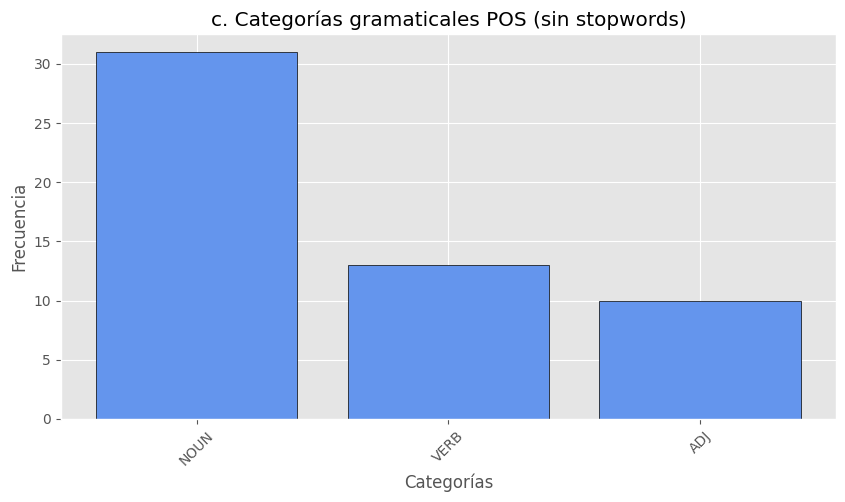

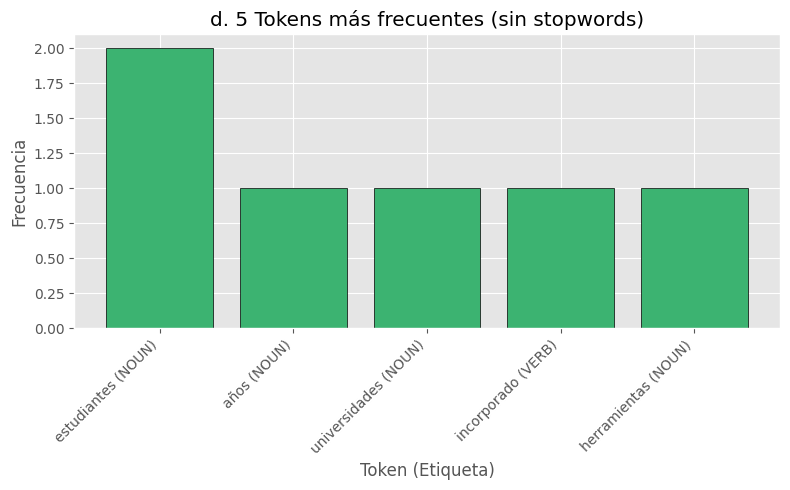

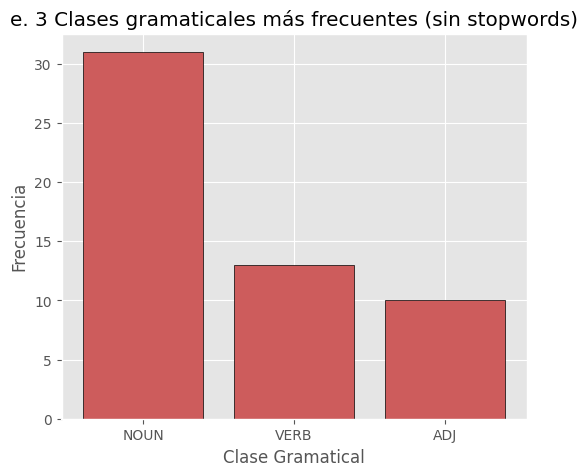

In [32]:
# Visualización de datos
plt.style.use('ggplot')

# Categorías gramaticales
plt.figure(figsize=(10, 5))
plt.bar(pos_labels_f, pos_values_f, color='cornflowerblue', edgecolor='black')
plt.title("c. Categorías gramaticales POS (sin stopwords)")
plt.xlabel("Categorías")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.show()

# Top 5 Tokens
plt.figure(figsize=(8, 5))
plt.bar(top5_labels_f, top5_values_f, color='mediumseagreen', edgecolor='black')
plt.title("d. 5 Tokens más frecuentes (sin stopwords)")
plt.xlabel("Token (Etiqueta)")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Top 3 Clases gramaticales
plt.figure(figsize=(6, 5))
plt.bar(top3_labels_f, top3_values_f, color='indianred', edgecolor='black')
plt.title("e. 3 Clases gramaticales más frecuentes (sin stopwords)")
plt.xlabel("Clase Gramatical")
plt.ylabel("Frecuencia")
plt.show()

In [36]:
print("==================================================================")
for pos, count in pos_counts_f.most_common():
    print(f"Categoría (UPOS): {pos:<6} | Frecuencia: {count}")
print("==================================================================")
for token_etiqueta, count in top5_tokens_f:
    print(f"{token_etiqueta:<20} | Frecuencia: {count}")
print("==================================================================")
for pos, count in top3_pos_f:
    print(f"Clase Gramatical: {pos:<6} | Frecuencia: {count}")
print("==================================================================")

Categoría (UPOS): NOUN   | Frecuencia: 31
Categoría (UPOS): VERB   | Frecuencia: 13
Categoría (UPOS): ADJ    | Frecuencia: 10
estudiantes (NOUN)   | Frecuencia: 2
años (NOUN)          | Frecuencia: 1
universidades (NOUN) | Frecuencia: 1
incorporado (VERB)   | Frecuencia: 1
herramientas (NOUN)  | Frecuencia: 1
Clase Gramatical: NOUN   | Frecuencia: 31
Clase Gramatical: VERB   | Frecuencia: 13
Clase Gramatical: ADJ    | Frecuencia: 10


**Conclusiones 2:**<br>
Al realizar el filtrado afecta las palabras más frecuentes que ahora son: "estudiantes", "universidades", "herramientas" e "incorporado". Ahora podemos observar que el tema del texto es el uso de herramientas tecnológicas en universidades.